# Prüfungsleistung - Strukturierte Informationsextraktion aus Stellenanzeigen

**Name:** *Jakob Wilmesmeier*

---

## Kontext: Die JobMatch-Plattform

Die (fiktive) HR-Tech-Firma **JobMatch** betreibt eine Karriereplattform, auf der Bewerber:innen passende Stellenanzeigen finden. Täglich werden tausende Anzeigen aus dem Web gecrawlt, aber als unstrukturierter Volltext sind sie für die Nutzer:innen kaum filterbar.

JobMatch braucht ein Modell, das aus jeder Anzeige genau die Felder extrahiert, nach denen Bewerber:innen tatsächlich filtern: Jobtitel, Unternehmen, Erfahrungslevel, Skills, Bildungsanforderungen, Gehaltsspanne und Benefits.

## Aufgabe

Entwickle ein Modell, das aus einer englischsprachigen Stellenanzeige (Freitext) ein strukturiertes JSON-Objekt mit sieben vordefinierten Feldern extrahiert:

```json
{
  "job_title":              "Senior Data Engineer",
  "company":                "Acme Corp",
  "experience_level":       "senior",
  "required_skills":        ["Python", "SQL", "Airflow"],
  "education_requirements": "Bachelor's degree in Computer Science",
  "salary_range":           {"min": 80000, "max": 110000, "currency": "USD"},
  "compensation_benefits":  ["health insurance", "401k matching", "remote work"]
}
```

Feldtypen im Detail:
- `job_title` (string): Bezeichnung der Stelle
- `company` (string): Name des Unternehmens
- `experience_level` (enum): Einer von `entry`, `junior`, `mid`, `senior`, `lead`, `executive`, `unknown`
- `required_skills` (list[string]): Geforderte technische oder fachliche Skills
- `education_requirements` (string): Bildungsanforderungen (oder leerer String)
- `salary_range` (object): `{min, max, currency}`, jeweils `null` wenn nicht angegeben
- `compensation_benefits` (list[string]): Benefits (Versicherungen, Urlaub, Remote etc.)

Felder können leer sein, wenn die Anzeige keine entsprechende Information enthält (leerer String, leere Liste, `null`-Subfelder bei `salary_range`).

**Inferenz-Laufzeit**: Das Ausführen des Auswertungs-Abschnitts (Modell laden + `predict()` auf 50 Testanzeigen + `evaluate()`) darf insgesamt maximal 20 Minuten dauern, gemessen auf einer Colab-T4-GPU. Plane dein Modell entsprechend. Bei Überschreitung gibt es Abzug in der manuellen Bewertung (siehe weiter unten).

## Datensatz

Du erhältst eine ZIP-Datei `train_data.zip` mit Trainingsdaten: Paare aus `.txt`-Anzeige und `.json`-Label im obigen Schema. Auf den Testdaten (die du nicht siehst) wird dein Modell am Ende automatisch bewertet.

## Abgabe

Du gibst eine **ZIP-Datei** ab, die folgendes enthält:

- `notebook.ipynb` – dieses Notebook, mit deinen Implementierungen
- `model/` – ein Ordner mit deinem trainierten Modell (Tokenizer, Modellgewichte, ggf. weitere Artefakte wie Mapping-Dictionaries)

Ich werde **nur die Zellen bis einschließlich der Auswertung** ausführen. Dein Trainings-Code wird **nicht** erneut ausgeführt, sondern nur gesichtet. Daher ist es sehr wichtig, dass dein Modell in der `predict()`-Funktion korrekt aus dem `model/`-Ordner geladen wird.

## Bewertung

Insgesamt **30 Punkte**:

### 10 Punkte automatisch

Berechnet über `evaluate()` als Macro-F1 über alle 7 Felder.
- Macro-F1 < 0.3 → 0 Punkte
- Macro-F1 ≥ 0.85 → 10 Punkte
- dazwischen linear

### 20 Punkte manuell

In fünf Bereichen à 4 Punkten:

| Bereich | Was wird bewertet? |
|---|---|
| **Methoden- und Modellwahl** | Passt das Modell zur Aufgabe? Begründet? Alternativen erwogen? |
| **Data Understanding & Preprocessing** | Sinnvoll exploriert? Preprocessing zur Modellwahl passend? Sauberer Split? |
| **Trainings- und Inferenz-Pipeline** | Reproduzierbar? Hyperparameter begründet? Code lesbar? |
| **Evaluation & Fehleranalyse** | Eigene Evaluation jenseits von `evaluate()`? F1 pro Feld? Schwächen erkannt? |
| **Reflexion & Begründung** | Werden Entscheidungen in Markdown-Zellen erklärt? Wissenschaftlicher Stil? |
---

## Vorbereitungen

Lasse die folgenden Zellen unverändert. Sie installieren benötigte Pakete, definieren das Zielschema und entpacken die Trainingsdaten.

### Installations

In [1]:
!pip install -U \
numpy==1.26.4 \
    pandas==2.2.2 \
    pyarrow==15.0.2 \
    datasets==2.20.0 \
    huggingface-hub==0.23.2 \
    transformers==4.44.2 \
    tokenizers==0.19.1 \
    accelerate==0.33.0 \
    sentencepiece==0.2.1 \
    fsspec==2024.2.0 \
    fsspec==2024.2.0 \
    peft==0.11.1 \
    matplotlib \
    scikit-learn \
    pydantic \
    hf_transfer

!pip uninstall -y torch torchvision torchaudio

!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu121
!pip install -q lm-format-enforcer

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached pandas-2.2.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached pyarrow-15.0.2-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached datasets-2.20.0-py3-none-any.whl.metadata (19 kB)
  Using cached huggingface_hub-0.23.2-py3-none-any.whl.metadata (12 kB)
  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
  Using cached accelerate-0.33.0-py3-none-any.whl.metadata (18 kB)
  Using cached sentencepiece-0.2.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (10 kB)
  Using cached fsspec-2024.2.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached peft-0.11.1-py3-none-any.whl.metadata (13 kB)
  Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86

In [50]:
from enum import StrEnum
from typing import Optional
from pydantic import BaseModel, Field


class ExperienceLevel(StrEnum):
    ENTRY = "entry"
    JUNIOR = "junior"
    MID = "mid"
    SENIOR = "senior"
    LEAD = "lead"
    EXECUTIVE = "executive"
    UNKNOWN = "unknown"


class SalaryRange(BaseModel):
    min: Optional[int] = None
    max: Optional[int] = None
    currency: Optional[str] = None


class JobPosting(BaseModel):
    job_title: str = ""
    company: str = ""
    experience_level: ExperienceLevel = ExperienceLevel.UNKNOWN
    required_skills: list[str] = Field(default_factory=list)
    education_requirements: str = ""
    salary_range: SalaryRange = Field(default_factory=SalaryRange)
    compensation_benefits: list[str] = Field(default_factory=list)

In [3]:
import zipfile
from pathlib import Path

TRAIN_ZIP = Path("train_data.zip")
TRAIN_DIR = Path("train")

if not TRAIN_DIR.exists():
    with zipfile.ZipFile(TRAIN_ZIP) as zf:
        zf.extractall(".")
print(f"Train: {len(list(TRAIN_DIR.glob('*.txt')))} Anzeigen")

FileNotFoundError: [Errno 2] No such file or directory: 'train_data.zip'

## Modell laden und Inferenz

In diesem Abschnitt wird dein **trainiertes Modell aus dem `model/`-Ordner geladen** und die `predict()`-Funktion bereitgestellt. Dieser Abschnitt wird bei der Korrektur ausgeführt – die Trainings-Sektion (weiter unten) hingegen nicht.

Passe die folgenden Zellen so an, dass:
1. dein Modell und alle benötigten Artefakte aus dem lokalen `model/`-Ordner geladen werden,
2. die `predict()`-Funktion ein gültiges `JobPosting`-Objekt zurückgibt.

**Verändere die Signatur und den Rückgabetyp von `predict()` nicht.**

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from peft import PeftModel
# Lade hier dein trainiertes Modell und alle benötigten Artefakte aus dem `model/`-Ordner.
# Beispiel für ein Hugging-Face-Modell:
#
#   from transformers import AutoTokenizer, AutoModelForTokenClassification
#   MODEL_DIR = Path("model")
#   tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
#   model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR)

# ...
# model = AutoModelForCausalLM.from_pretrained("workspace/model",
#                                              device_map="cuda",
#                                              torch_dtype="auto")
# tokenizer = AutoTokenizer.from_pretrained("workspace/model")
model_name = "Qwen/Qwen2.5-1.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="cuda", torch_dtype="auto")
tokenizer = AutoTokenizer.from_pretrained(model_name)
peft_model = PeftModel.from_pretrained(model, "workspace/lora_adapter")


In [51]:
from pydantic import ValidationError
from lmformatenforcer import JsonSchemaParser
from lmformatenforcer.integrations.transformers import build_transformers_prefix_allowed_tokens_fn

def predict(text: str) -> JobPosting:
    parser = JsonSchemaParser(JobPosting.model_json_schema())
    prefix_fn = build_transformers_prefix_allowed_tokens_fn(tokenizer, parser)
    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": text
        }
    ]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(peft_model.device)

    output_ids = peft_model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=None,
        top_p=None,
        do_sample=False,
        prefix_allowed_tokens_fn=prefix_fn,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    output_ids = output_ids[0].cpu().tolist()

    job_posting_json = tokenizer.decode(output_ids[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(job_posting_json)

    try:
        job_obj = JobPosting.model_validate_json(job_posting_json)
    except ValidationError:
        print("ValidationError: Das generierte JSON entspricht nicht dem Schema.")
        job_obj = JobPosting(
            job_title="",
            company="",
            experience_level=ExperienceLevel.UNKNOWN,
            required_skills=[],
            education_requirements="",
            salary_range=SalaryRange(),
            compensation_benefits=[],
        )

    return job_obj

## Auswertung

**Lasse die `evaluate()`-Funktion unverändert.** Sie bewertet dein Modell und berechnet die automatischen Punkte (max. 10).

Während der Entwicklung kannst du `EVAL_DIR` in der nächsten Zelle z.B. auf `Path("train")` setzen, um die Evaluation auf den Trainingsdaten laufen zu lassen und ein erstes Gefühl für die Modellgüte zu bekommen. Die Performance auf den Trainingsdaten überschätzt allerdings, wie gut dein Modell auf neuen Daten generalisiert, ein eigener Train/Val-Split ist methodisch sauberer.

In [52]:
import json
import math
import time
from pathlib import Path


def _norm_text(s: str) -> str:
    """Normalisiert Strings für robusten Vergleich (lowercase, getrimmt, Whitespace zusammengezogen)."""
    return " ".join((s or "").lower().split())


def _f1(tp: int, fp: int, fn: int) -> float:
    if tp == 0:
        return 0.0
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    return 2 * precision * recall / (precision + recall)


def _score_string_field(pred: str, true: str) -> tuple[int, int, int]:
    """Für String-Felder: token-set-basierter F1. Liefert (tp, fp, fn)."""
    p_tokens = set(_norm_text(pred).split())
    t_tokens = set(_norm_text(true).split())
    if not p_tokens and not t_tokens:
        return (1, 0, 0)  # beide leer -> perfekter Match
    tp = len(p_tokens & t_tokens)
    fp = len(p_tokens - t_tokens)
    fn = len(t_tokens - p_tokens)
    return (tp, fp, fn)


def _score_enum_field(pred: str, true: str) -> tuple[int, int, int]:
    """Für Enum-Felder: exakter Match."""
    if pred == true:
        return (1, 0, 0)
    return (0, 1, 1)


def _score_list_field(pred: list[str], true: list[str]) -> tuple[int, int, int]:
    """Für Listen-Felder: Set-F1 mit normalisierten Items."""
    p_set = {_norm_text(x) for x in pred if x}
    t_set = {_norm_text(x) for x in true if x}
    if not p_set and not t_set:
        return (1, 0, 0)
    tp = len(p_set & t_set)
    fp = len(p_set - t_set)
    fn = len(t_set - p_set)
    return (tp, fp, fn)


def _score_salary_field(pred: dict, true: dict) -> tuple[int, int, int]:
    """Für salary_range: F1 über die drei Subfelder. Toleranz für min/max: 10%."""
    tp = fp = fn = 0
    for key in ("min", "max"):
        p_val, t_val = pred.get(key), true.get(key)
        if p_val is None and t_val is None:
            tp += 1
        elif p_val is None and t_val is not None:
            fn += 1
        elif p_val is not None and t_val is None:
            fp += 1
        else:
            # 10% Toleranz
            if abs(p_val - t_val) <= max(1000, 0.1 * t_val):
                tp += 1
            else:
                fp += 1
                fn += 1
    # Currency: exakt
    p_cur, t_cur = pred.get("currency"), true.get("currency")
    if p_cur is None and t_cur is None:
        tp += 1
    elif (p_cur or "").upper() == (t_cur or "").upper() and p_cur:
        tp += 1
    else:
        if p_cur is not None:
            fp += 1
        if t_cur is not None:
            fn += 1
    return (tp, fp, fn)


FIELD_SCORERS = {
    "job_title": _score_string_field,
    "company": _score_string_field,
    "experience_level": _score_enum_field,
    "required_skills": _score_list_field,
    "education_requirements": _score_string_field,
    "salary_range": _score_salary_field,
    "compensation_benefits": _score_list_field,
}

INFERENCE_TIME_LIMIT_SECONDS = 20 * 60  # 20 Minuten


def evaluate(test_folder: Path) -> int:
    """Bewertet das Modell auf dem Testset und gibt die automatischen Punkte (0-10) zurück."""
    test_folder = Path(test_folder)
    txt_files = sorted(test_folder.glob("*.txt"))
    if not txt_files:
        raise FileNotFoundError(f"Keine .txt-Dateien in {test_folder} gefunden.")

    field_counts = {f: [0, 0, 0] for f in FIELD_SCORERS}

    start_time = time.time()
    for txt_file in txt_files:
        json_file = txt_file.with_suffix(".json")
        if not json_file.exists():
            print(f"WARNUNG: Kein Label für {txt_file.name}, übersprungen.")
            continue

        text = txt_file.read_text(encoding="utf-8")
        true = json.loads(json_file.read_text(encoding="utf-8"))
        pred = predict(text).model_dump()

        for field, scorer in FIELD_SCORERS.items():
            tp, fp, fn = scorer(pred[field], true[field])
            field_counts[field][0] += tp
            field_counts[field][1] += fp
            field_counts[field][2] += fn
    inference_time = time.time() - start_time

    print("\n=== F1 pro Feld ===")
    f1_per_field = {}
    for field, (tp, fp, fn) in field_counts.items():
        f1 = _f1(tp, fp, fn)
        f1_per_field[field] = f1
        print(f"  {field:25s}  F1={f1:.3f}  (TP={tp}, FP={fp}, FN={fn})")

    macro_f1 = sum(f1_per_field.values()) / len(f1_per_field)
    print(f"\nMacro-F1: {macro_f1:.3f}")

    # Punkteberechnung: <0.3 -> 0 Punkte, >=0.85 -> 10 Punkte, dazwischen linear
    if macro_f1 < 0.3:
        points = 0
    else:
        points = min(10, math.ceil((macro_f1 - 0.3) * 18))
    print(f"Automatische Punkte: {points} / 10")

    # Inferenz-Laufzeit
    print(f"\nInferenzzeit: {inference_time:.1f}s "
          f"({inference_time/len(txt_files):.2f}s pro Anzeige)")
    if inference_time > INFERENCE_TIME_LIMIT_SECONDS:
        print(f"WARNUNG: Inferenz hat das 20-Minuten-Limit überschritten "
              f"({inference_time/60:.1f} Min).")

    return points

In [ ]:
# TEST_ZIP = Path("test_data.zip")
# TEST_DIR = Path("test")
# if not TEST_DIR.exists() and TEST_ZIP.exists():
#     with zipfile.ZipFile(TEST_ZIP) as zf:
#         zf.extractall(".")
# print(f"Test: {len(list(TEST_DIR.glob('*.txt')))} Anzeigen")

In [53]:
# Während der Entwicklung kannst du EVAL_DIR z.B. auf Path("train") setzen,
# um die Evaluation auf den Trainingsdaten auszuprobieren.
# Für die offizielle Bewertung wird hier Path("test") gesetzt.
EVAL_DIR = Path("workspace/test")

evaluate(EVAL_DIR)

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


{"job_title": "Senior Sales Marketing Specialist - Programmatic", "company": "The Trade Desk", "experience_level": "mid", "required_skills": ["passionate and knowledgeable about the ad tech ecosystem and the programmatic industry", "experienced working across several channels (preferably including CTV and DOOH)"], "education_requirements": "4-year college degree level education"}
{"job_title": "Construction Project Manager", "company": "Tractor Supply Company", "experience_level": "mid", "required_skills": ["construction management", "project management", "contractual knowledge"], "education_requirements": "Bachelor's degree in Construction Management or related field", "salary_range": {"min": null, "max": null}, "compensation_benefits": []}
{"job_title": "Senior Manager, Test Engineering", "company": "Helix", "experience_level": "senior", "required_skills": ["years leading test engineering teams", "proven track record driving adoption of manual and automated testing in a fast paced ag

4

---

# Trainings-Dokumentation

**Hinweis:** Der folgende Abschnitt dokumentiert dein Vorgehen beim Training. Er wird bei der Korrektur **nicht** ausgeführt, sondern nur gesichtet (das fertige Modell liegt ja bereits im `model/`-Ordner und wird oben geladen).

Dieser Abschnitt fließt in die **manuelle Bewertung** ein. Achte auf:
- Nachvollziehbare Darstellung deiner Entscheidungen (in Markdown-Zellen)
- Reproduzierbarer Code (falls jemand das Training nachvollziehen will)
- Sinnvolle Visualisierungen und Statistiken

## Data Understanding

Untersuche die bereitgestellten Daten. Sinnvolle Fragen können sein:
- Wie lang sind die Anzeigen typischerweise (in Tokens / Zeichen)?
- Wie ist die Verteilung der `experience_level`-Klassen?
- Wie viele Anzeigen enthalten überhaupt eine Gehaltsangabe?
- Welche Skills tauchen am häufigsten auf?

Diese Einsichten helfen dir, das richtige Modell und passende Preprocessing-Schritte zu wählen.

In [3]:
from pathlib import Path
import json
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)

train_folder = Path("./workspace/train")
txt_files = sorted(train_folder.glob("*.txt"))

rows = []
for txt_file in txt_files:
    json_file = txt_file.with_suffix(".json")
    if not json_file.exists():
        continue

    text = txt_file.read_text(encoding="utf-8")
    labels = json.loads(json_file.read_text(encoding="utf-8"))

    salary = labels.get("salary_range", {}) or {}
    skills = labels.get("required_skills", []) or []
    benefits = labels.get("compensation_benefits", []) or []

    rows.append({
        "text": text,
        "char_len": len(text),
        "word_len": len(text.split()),
        "job_title": labels.get("job_title", ""),
        "company": labels.get("company", ""),
        "experience_level": labels.get("experience_level", ""),
        "education_requirements": labels.get("education_requirements", ""),
        "required_skills": skills,
        "skill_count": len(skills),
        "compensation_benefits": benefits,
        "benefit_count": len(benefits),
        "salary_min": salary.get("min"),
        "salary_max": salary.get("max"),
        "salary_currency": salary.get("currency"),
        "has_salary": salary.get("min") is not None or salary.get("max") is not None
    })

analysis_df = pd.DataFrame(rows)
analysis_df


,text,char_len,word_len,job_title,company,experience_level,education_requirements,required_skills,skill_count,compensation_benefits,benefit_count,salary_min,salary_max,salary_currency,has_salary
0,description\n\nabout this role\n\noverview\n\nwith most of the assets we manage related to retirement our firm has a...,5565,797,"Integrated Marketing, VP (Retirement Group)",BlackRock,executive,,"[5+ years in marketing, Proven success building and executing integrated marketing strategies, Strong creative marke...",5,"[Competitive retirement plan, tuition reimbursement, healthcare, working parent support, flexible time off]",5,NaN,NaN,None,False
1,due to covid in effort to embrace social distancing the company overview will be conducted online via zoom\n\nwe are...,1360,205,Customer Service Representative / Remote,American Income Life Insurance Company,unknown,,"[Previous experience in customer service, sales, or related fields, ability to build rapport with clients, prioritiz...",7,"[Weekly pay, bonuses, residual income, company-paid trips, remote work]",5,NaN,NaN,None,False
2,purpose\nthe warehouse supervisor is responsible for directing and overseeing the warehouse operations of each retai...,5734,808,Warehouse Supervisor,Floor & Decor,junior,,"[2+ years of supervisory experience in a warehouse/distribution environment, strong interpersonal and team managemen...",4,"[Bonus opportunities, career advancement, relocation opportunities, 401(k) with company match, employee stock purcha...",8,NaN,NaN,None,False
3,description hughes private capital in business since and one of the fastest growing companies in northern nevada is...,7661,1097,Software Engineer,Hughes Private Capital LLC,junior,,"[Object-oriented programming, 2+ years of software engineering experience, 2+ years of full stack web development ex...",15,"[Competitive salary, health benefits, paid vacation time, paid sick time, paid federal holidays, employee investment...",6,NaN,NaN,None,False
4,description\n\ndevelops and implements effective nursing staff education using a variety of teaching techniques to e...,1171,156,Clinical Educator Part Time,University Hospitals Careers,unknown,,"[RN license, progressive clinical experience, teaching/training skills, human relations skills, expertise in utilizi...",5,[],0,NaN,NaN,None,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,overview\n\nthe real estate industry is still operating on excel sheets passed back and forth lacking transparency i...,5102,844,CEO/Co-Founder,Juliet,executive,,"[Startup experience in C-suite role, real estate experience in leasing/revenue management, product management experi...",4,"[Competitive compensation and benefits, equity, fun and supportive work environment]",3,NaN,NaN,None,False
645,your job\n\nif you are an engineer whos passionate about building innovative products that scale to tens of millions...,5898,895,Staff Software Engineer - SMB - Marketing Enablement,Indeed,mid,"BS degree or above in computer science, computer engineering, electrical engineering, mathematics or a closely relat...","[3+ years of experience programming in Java, C++, Python or Go, BS degree or above in computer science, computer eng...",10,"[Salary range: $100000 - $150000 USD per year, Benefits include quarterly bonuses, restricted stock units, open paid...",5,100000.0,150000.0,USD,True
646,one of our clients a global market research company is looking for a talented programmer analyst with r consultant\n...,2549,385,Programmer Analyst with R Consultant,Brains Workgroup,junior,,"[2+ years of R programming experience, Experience with dplyr and testthat R packages preferred, Ability to read and ...",4,[],0,NaN,NaN,None,False
647,job goal to provide instructional services resources and direction to those staff members who are directly responsi...,1002,135,Special education coordinator,Pickerington Local School District,executive,"valid ohio teaching license, certificate education of the handicapp

In [4]:
overview_table = pd.DataFrame({
    "Metrik": [
        "Dokumente",
        "Ø Zeichen",
        "Median Zeichen",
        "Ø Wörter",
        "Median Wörter",
        "Anteil mit Gehaltsangabe",
        "Ø Skills pro Anzeige",
        "Ø Benefits pro Anzeige"
    ],
    "Wert": [
        len(analysis_df),
        round(analysis_df["char_len"].mean(), 1),
        int(analysis_df["char_len"].median()),
        round(analysis_df["word_len"].mean(), 1),
        int(analysis_df["word_len"].median()),
        f"{analysis_df['has_salary'].mean() * 100:.1f}%",
        round(analysis_df["skill_count"].mean(), 2),
        round(analysis_df["benefit_count"].mean(), 2)
    ]
})

missingness_table = pd.DataFrame({
    "Feld": [
        "job_title", "company", "experience_level", "education_requirements",
        "required_skills", "compensation_benefits", "salary_min", "salary_max", "salary_currency"
    ]
})

missingness_table["Fehlend (%)"] = [
    (analysis_df[col].isna() | (analysis_df[col] == "") | (analysis_df[col].astype(str) == "[]")).mean() * 100
    for col in missingness_table["Feld"]
]
missingness_table["Fehlend (%)"] = missingness_table["Fehlend (%)"].round(2)

display(overview_table)
display(missingness_table.sort_values("Fehlend (%)", ascending=False))


,Metrik,Wert
0,Dokumente,649
1,Ø Zeichen,3375.6
2,Median Zeichen,3036
3,Ø Wörter,488.2
4,Median Wörter,439
5,Anteil mit Gehaltsangabe,2.0%
6,Ø Skills pro Anzeige,6.17
7,Ø Benefits pro Anzeige,2.36


,Feld,Fehlend (%)
7,salary_max,98.00
6,salary_min,98.00
8,salary_currency,98.00
5,compensation_benefits,58.24
3,education_requirements,46.53
4,required_skills,3.85
0,job_title,0.00
1,company,0.00
2,experience_level,0.00


/tmp/ipykernel_510/3013401617.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(analysis_df["skill_count"], vert=False, patch_artist=True, boxprops=dict(facecolor="#8172B3", alpha=0.7))


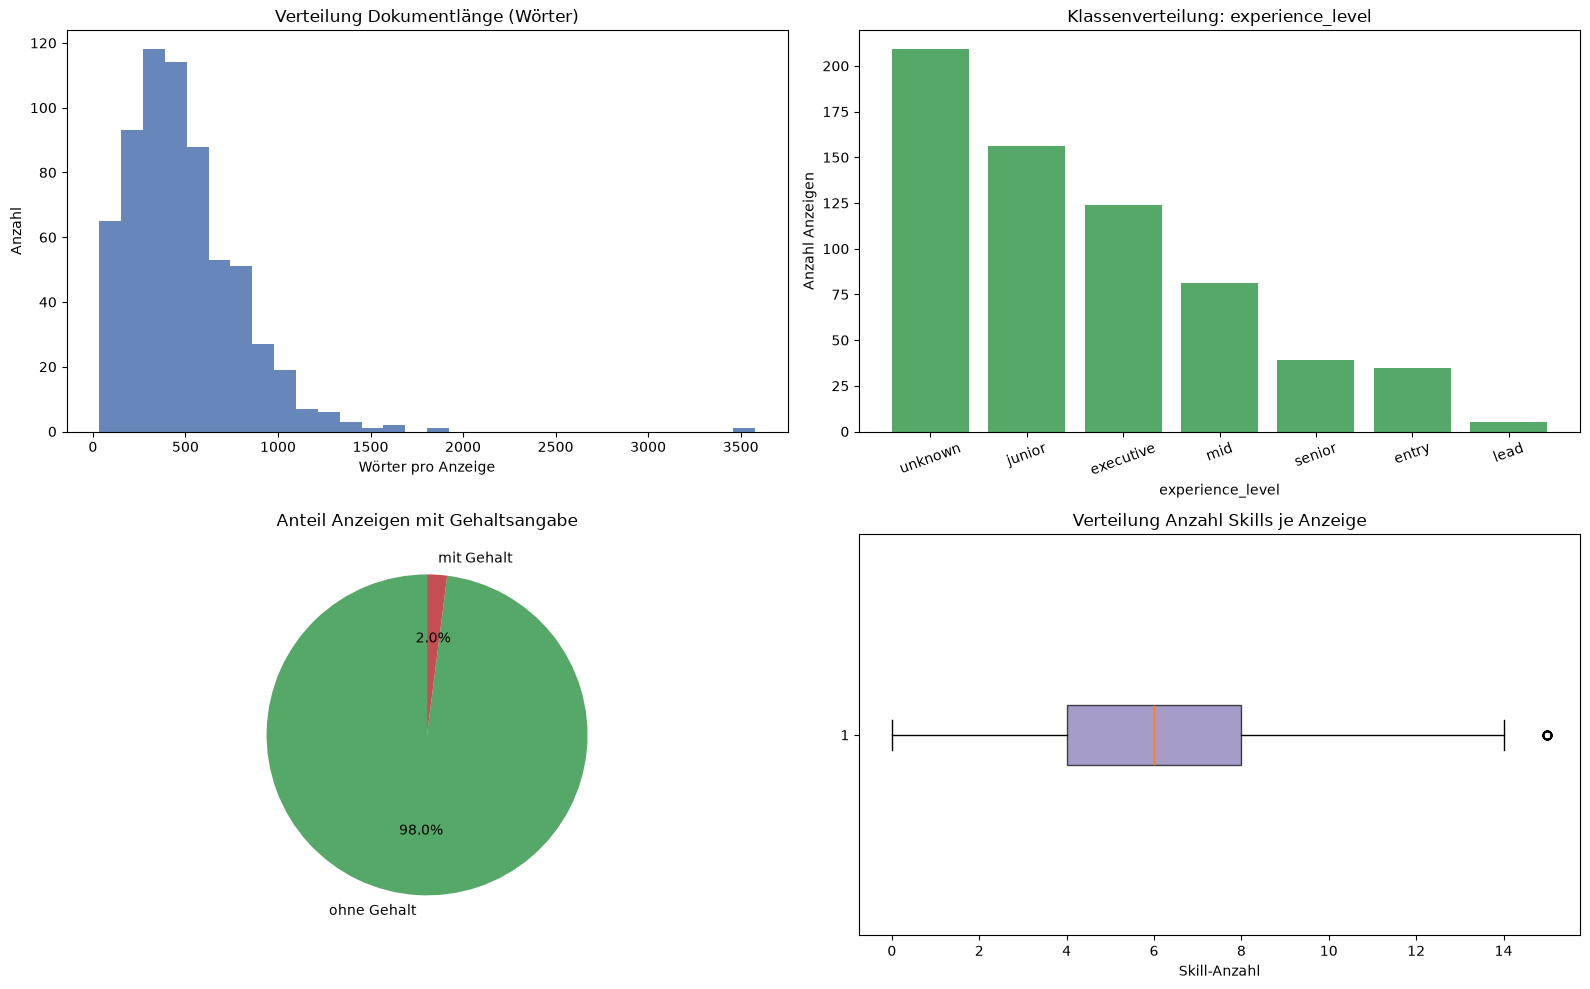

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(analysis_df["word_len"], bins=30, color="#4C72B0", alpha=0.85)
axes[0, 0].set_title("Verteilung Dokumentlänge (Wörter)")
axes[0, 0].set_xlabel("Wörter pro Anzeige")
axes[0, 0].set_ylabel("Anzahl")

exp_counts = analysis_df["experience_level"].fillna("unbekannt").replace("", "unbekannt").value_counts()
axes[0, 1].bar(exp_counts.index.astype(str), exp_counts.values, color="#55A868")
axes[0, 1].set_title("Klassenverteilung: experience_level")
axes[0, 1].set_xlabel("experience_level")
axes[0, 1].set_ylabel("Anzahl Anzeigen")
axes[0, 1].tick_params(axis="x", rotation=20)

salary_counts = analysis_df["has_salary"].map({True: "mit Gehalt", False: "ohne Gehalt"}).value_counts()
axes[1, 0].pie(salary_counts.values, labels=salary_counts.index, autopct="%1.1f%%", startangle=90, colors=["#55A868", "#C44E52"])
axes[1, 0].set_title("Anteil Anzeigen mit Gehaltsangabe")

axes[1, 1].boxplot(analysis_df["skill_count"], vert=False, patch_artist=True, boxprops=dict(facecolor="#8172B3", alpha=0.7))
axes[1, 1].set_title("Verteilung Anzahl Skills je Anzeige")
axes[1, 1].set_xlabel("Skill-Anzahl")

plt.tight_layout()
plt.show()


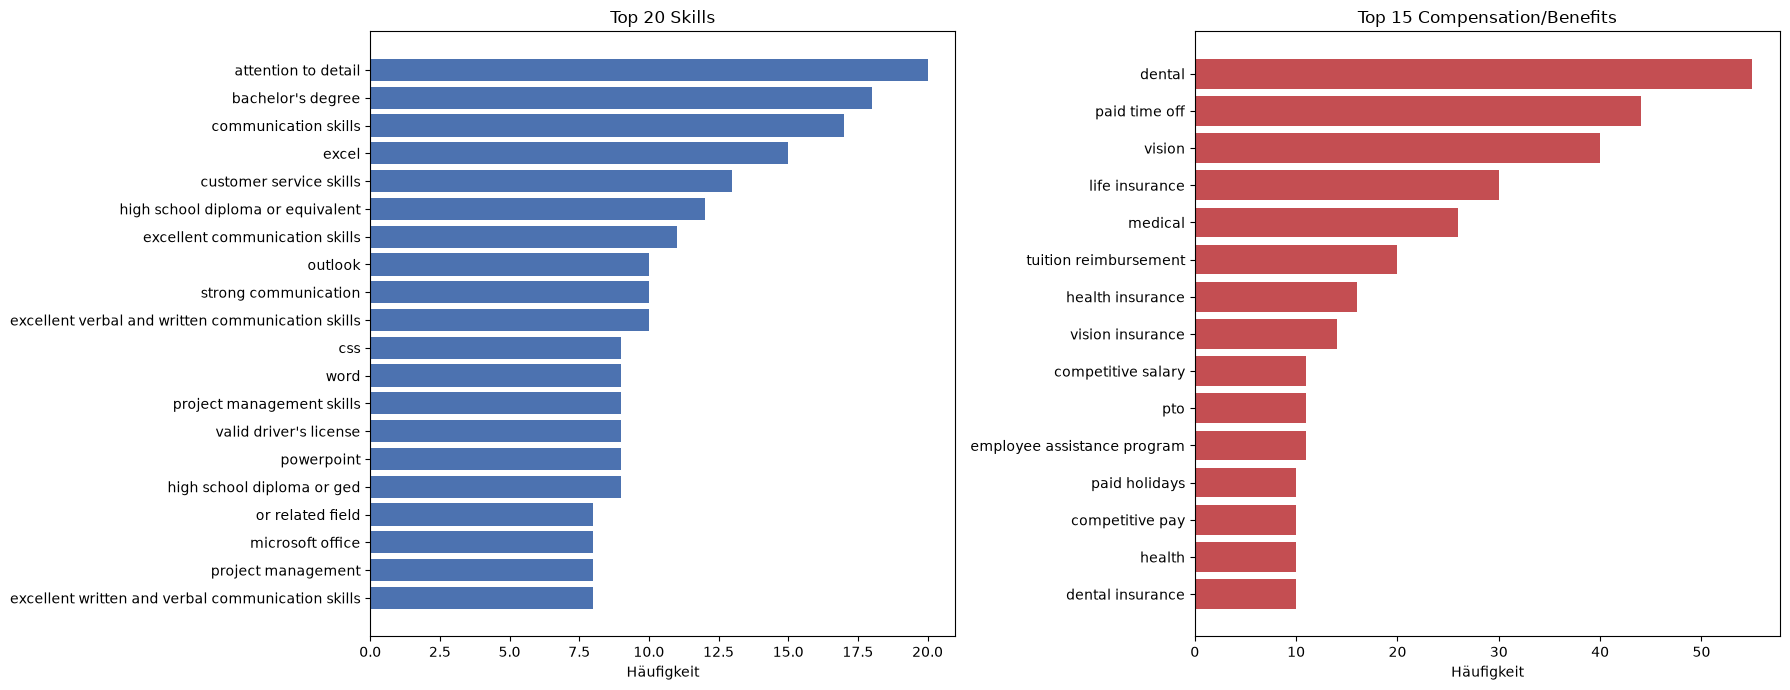

,Skill,Häufigkeit
0,attention to detail,20
1,bachelor's degree,18
2,communication skills,17
3,excel,15
4,customer service skills,13
5,high school diploma or equivalent,12
6,excellent communication skills,11
7,outlook,10
8,strong communication,10
9,excellent verbal and written communication skills,10


,Benefit,Häufigkeit
0,dental,55
1,paid time off,44
2,vision,40
3,life insurance,30
4,medical,26
5,tuition reimbursement,20
6,health insurance,16
7,vision insurance,14
8,competitive salary,11
9,pto,11


In [6]:
skill_counter = Counter(skill.strip().lower() for skills in analysis_df["required_skills"] for skill in skills if skill)
benefit_counter = Counter(benefit.strip().lower() for benefits in analysis_df["compensation_benefits"] for benefit in benefits if benefit)

top_skills = pd.DataFrame(skill_counter.most_common(20), columns=["Skill", "Häufigkeit"])
top_benefits = pd.DataFrame(benefit_counter.most_common(15), columns=["Benefit", "Häufigkeit"])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].barh(top_skills["Skill"], top_skills["Häufigkeit"], color="#4C72B0")
axes[0].invert_yaxis()
axes[0].set_title("Top 20 Skills")
axes[0].set_xlabel("Häufigkeit")

axes[1].barh(top_benefits["Benefit"], top_benefits["Häufigkeit"], color="#C44E52")
axes[1].invert_yaxis()
axes[1].set_title("Top 15 Compensation/Benefits")
axes[1].set_xlabel("Häufigkeit")

plt.tight_layout()
plt.show()

display(top_skills.head(20))
display(top_benefits.head(15))


### Ableitungen für Data Cleansing, Preprocessing und Normalisierung

- **Längenverteilung prüfen und begrenzen:** Nutze Quantile (z. B. 95%-Quantil der `word_len`) für sinnvolle Max-Längen beim Tokenisieren (`truncation`) und vermeide zu aggressive Kürzungen.
- **Fehlende/uneinheitliche Felder standardisieren:** Leere Strings und fehlende Werte in Labeln vereinheitlichen (z. B. `None`/`[]`) und vor dem Training in ein konsistentes Schema überführen.
- **Klassengewichte bei `experience_level` erwägen:** Bei Schieflage der Klassenverteilung helfen gewichtete Loss-Funktionen oder gezieltes Sampling.
- **Skills normalisieren:** Schreibweisen vereinheitlichen (Lowercase, Trimmen, Synonyme wie `ml` vs. `machine learning`) für robustere Targets und sauberere Evaluation.
- **Gehaltsfelder harmonisieren:** `salary_min`, `salary_max`, `salary_currency` validieren (Typen, Bereichsgrenzen, Währungskonsistenz) und bei Bedarf auf eine Referenzwährung normalisieren.
- **Outlier-Handling vorbereiten:** Sehr kurze/lange Anzeigen und extrem viele Skills als potenzielle Ausreißer kennzeichnen und deren Einfluss auf Training separat bewerten.


In [35]:
import unicodedata

EXPERIENCE_MAP = {
    "jr": "junior", "entry level": "junior", "junior": "junior",
    "mid": "mid", "intermediate": "mid",
    "sr": "senior", "senior": "senior",
    "lead": "lead"
}

SKILL_MAP = {
    "ml": "machine learning",
    "machine-learning": "machine learning",
    "py": "python"
}

def _norm_text(x):
    if x is None:
        return None
    x = unicodedata.normalize("NFKC", str(x)).strip()
    x = " ".join(x.split())
    if x.lower() in {"", "n/a", "na", "keine angabe", "-", "none"}:
        return None
    return x

def _norm_list(values, mapping=None):
    mapping = mapping or {}
    out, seen = [], set()
    for v in (values or []):
        t = _norm_text(v)
        if not t:
            continue
        t = mapping.get(t.lower(), t.lower())
        if t not in seen:
            seen.add(t)
            out.append(t)
    return out

def _to_float(v):
    try:
        return float(v) if v is not None else None
    except Exception:
        return None

def normalize_labels(labels):
    out = []
    for json_text in labels:
        job = dict(json.loads(json_text))

        job["job_title"] = _norm_text(job.get("job_title"))
        job["company"] = _norm_text(job.get("company"))
        job["education_requirements"] = _norm_text(job.get("education_requirements"))

        exp = _norm_text(job.get("experience_level"))
        exp = exp.lower() if exp else "unknown"
        job["experience_level"] = EXPERIENCE_MAP.get(exp, exp)

        job["required_skills"] = _norm_list(job.get("required_skills"), SKILL_MAP)
        job["compensation_benefits"] = _norm_list(job.get("compensation_benefits"))

        salary = job.get("salary_range") or {}
        mn = _to_float(salary.get("min"))
        mx = _to_float(salary.get("max"))
        cur = _norm_text(salary.get("currency"))
        if mn is not None and mx is not None and mn > mx:
            mn, mx = mx, mn
        if mn is not None and mn < 0:
            mn = None
        if mx is not None and mx < 0:
            mx = None

        job["salary_range"] = {
            "min": mn,
            "max": mx,
            "currency": cur.upper() if cur else None
        }
        job_text = json.dumps(job, ensure_ascii=False)
        out.append(job_text)
    return out

## Data Preprocessing

Bereite die Daten so vor, dass sie zu deinem gewählten Modellansatz passen.
Mögliche Schritte: Tokenisierung, Konvertierung in Seq2Seq-Format (z.B. `text -> JSON-String`), Erzeugung von BIO-Tags für NER, Train/Val-Split, etc.

In [36]:
from pathlib import Path
import json
import pandas as pd
from sklearn.model_selection import train_test_split

train_folder = Path("./workspace/train")
txt_files = sorted(train_folder.glob("*.txt"))

if not txt_files:
    raise FileNotFoundError(f"Keine .txt-Dateien in {train_folder} gefunden.")

rows = []

for txt_file in txt_files:
    json_file = txt_file.with_suffix(".json")

    if not json_file.exists():
        print(f"WARNUNG: Kein Label für {txt_file.name}, übersprungen.")
        continue

    text = txt_file.read_text(encoding="utf-8")
    labels = json.loads(json_file.read_text(encoding="utf-8"))

    row = {
        "filename": txt_file.stem,
        "text": text,
        "label": json.dumps(labels, ensure_ascii=False)
    }

    rows.append(row)

df = pd.DataFrame(rows)

print(df.head())
print(f"Anzahl Dokumente: {len(df)}")

   filename  \
0  job_0000   
1  job_0001   
2  job_0002   
3  job_0003   
4  job_0004   

                                                                                                                      text  \
0  description\n\nabout this role\n\noverview\n\nwith most of the assets we manage related to retirement our firm has a...   
1  due to covid in effort to embrace social distancing the company overview will be conducted online via zoom\n\nwe are...   
2  purpose\nthe warehouse supervisor is responsible for directing and overseeing the warehouse operations of each retai...   
3  description hughes private capital in business since  and one of the fastest growing companies in northern nevada is...   
4  description\n\ndevelops and implements effective nursing staff education using a variety of teaching techniques to e...   

                                                                                                                     label  
0  {"job_title": "Integrate

In [37]:
df["label"] = normalize_labels(df["label"])
df["label"]

0      {"job_title": "Integrated Marketing, VP (Retirement Group)", "company": "BlackRock", "experience_level": "executive"...
1      {"job_title": "Customer Service Representative / Remote", "company": "American Income Life Insurance Company", "expe...
2      {"job_title": "Warehouse Supervisor", "company": "Floor & Decor", "experience_level": "junior", "required_skills": [...
3      {"job_title": "Software Engineer", "company": "Hughes Private Capital LLC", "experience_level": "junior", "required_...
4      {"job_title": "Clinical Educator Part Time", "company": "University Hospitals Careers", "experience_level": "unknown...
                                                                ...                                                           
644    {"job_title": "CEO/Co-Founder", "company": "Juliet", "experience_level": "executive", "required_skills": ["startup e...
645    {"job_title": "Staff Software Engineer - SMB - Marketing Enablement", "company": "Indeed", "experience_l

In [38]:
df["exp_level"] = df["label"].apply(lambda s: (json.loads(s).get("experience_level") or "unknown").strip().lower())

# seltene Klassen, die sonst Split-Fehler erzeugen, auf "other" mappen
min_count = 2
counts = df["exp_level"].value_counts()
rare = counts[counts < min_count].index
df["exp_level_strat"] = df["exp_level"].where(~df["exp_level"].isin(rare), "other")

train_df, eval_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=df["exp_level_strat"],
)

train_df = train_df.drop(columns=["exp_level", "exp_level_strat"], errors="ignore")
eval_df = eval_df.drop(columns=["exp_level", "exp_level_strat"], errors="ignore")

print(f"Train: {len(train_df)}")
print(f"Val: {len(eval_df)}")

Train: 519
Val: 130


In [39]:
from sklearn.utils.class_weight import compute_class_weight

exp = train_df["label"].apply(lambda s: (json.loads(s).get("experience_level") or "unknown").strip().lower())
classes = np.array(sorted(exp.unique()), dtype=object)
y = exp.to_numpy(dtype=object)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y,
)

class_weight_map = {c: float(w) for c, w in zip(classes, weights)}
print("class_weight_map:", class_weight_map)

train_df = train_df.copy()
train_df["sample_weight"] = train_df["label"].apply(
    lambda s: class_weight_map.get((json.loads(s).get("experience_level") or "unknown").strip().lower(), 1.0)
)

eval_df = eval_df.copy()
eval_df["sample_weight"] = 1.0  # eval ungewichtet

class_weight_map: {'entry': 2.6479591836734695, 'executive': 0.7489177489177489, 'junior': 0.5931428571428572, 'lead': 18.535714285714285, 'mid': 1.1406593406593406, 'senior': 2.391705069124424, 'unknown': 0.4439692044482464}


In [40]:
from datasets import Dataset

train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
eval_ds = Dataset.from_pandas(eval_df.reset_index(drop=True))

In [6]:
import json
from collections import Counter

bad = 0
starts = Counter()
examples = []

for x in train_ds.select(range(min(500, len(train_ds)))):
    y = x["label"]
    s = y.strip() if isinstance(y, str) else str(y)
    starts[s[:1]] += 1
    try:
        json.loads(s)
    except Exception:
        bad += 1
        if len(examples) < 5:
            examples.append(s[:300])

print("invalid json:", bad)
print("start chars:", starts.most_common(10))
print("bad examples:")
for e in examples:
    print("---", e)

invalid json: 0
start chars: [('{', 448)]
bad examples:


In [15]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(
    model_name
)

In [41]:
system_prompt = "Extract structured information from job advertisements and answer only with valid JSON."
max_length = 2048
max_target_tokens = 512


def preprocess_inputs(samples):
    input_ids_list = []
    attention_masks = []
    labels_list = []
    sample_weights = []

    for text, target, w in zip(samples["text"], samples["label"], samples.get("sample_weight", [1.0] * len(samples["text"]))):
        prompt_msgs = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text},
        ]

        prompt_ids = tokenizer.apply_chat_template(
            prompt_msgs,
            tokenize=True,
            add_generation_prompt=True,
        )

        target_ids = tokenizer(target, add_special_tokens=False)["input_ids"]
        target_ids = target_ids[:max_target_tokens] + [tokenizer.eos_token_id]

        available_for_prompt = max_length - len(target_ids)
        if available_for_prompt <= 0:
            # extrem langes Json
            continue

        if len(prompt_ids) > available_for_prompt:
            sys_prompt_ids = tokenizer.apply_chat_template(
                [{"role": "system", "content": system_prompt},
                 {"role": "user", "content": ""}],
                tokenize=True,
                add_generation_prompt=True,
            )
            system_overhead = len(sys_prompt_ids)

            user_budget = max(16, available_for_prompt - system_overhead)
            user_ids = tokenizer(text, add_special_tokens=False)["input_ids"][:user_budget]
            text_cut = tokenizer.decode(user_ids, skip_special_tokens=True)

            prompt_msgs = [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": text_cut},
            ]
            prompt_ids = tokenizer.apply_chat_template(
                prompt_msgs,
                tokenize=True,
                add_generation_prompt=True,
            )

            # falls wegen Template-Overhead noch minimal zu lang
            prompt_ids = prompt_ids[:available_for_prompt]

        input_ids = prompt_ids + target_ids
        input_ids = input_ids[:max_length]

        labels = [-100] * len(prompt_ids) + target_ids
        labels = labels[:max_length]

        attention_mask = [1] * len(input_ids)

        pad_len = max_length - len(input_ids)
        input_ids += [tokenizer.pad_token_id] * pad_len
        attention_mask += [0] * pad_len
        labels += [-100] * pad_len

        input_ids_list.append(input_ids)
        attention_masks.append(attention_mask)
        labels_list.append(labels)
        sample_weights.append(float(w))

    return {
        "input_ids": input_ids_list,
        "attention_mask": attention_masks,
        "labels": labels_list,
        "sample_weight": sample_weights
    }

In [42]:
tokenized_train_ds = train_ds.map(preprocess_inputs, batched=True, remove_columns=train_ds.column_names, keep_in_memory=False, )

Map:   0%|          | 0/519 [00:00<?, ? examples/s]

In [43]:
tokenized_eval_ds = eval_ds.map(preprocess_inputs, batched=True, remove_columns=eval_ds.column_names, keep_in_memory=False, )

Map:   0%|          | 0/130 [00:00<?, ? examples/s]

In [11]:
import numpy as np

# 1) Verteilung der supervised Tokens im bereits tokenisierten Train-Datensatz
supervised_counts = []
seq_lens = []
ratios = []

for ex in tokenized_train_ds:
    lbl = ex["labels"]
    n_sup = sum(t != -100 for t in lbl)
    n_len = len(lbl)
    supervised_counts.append(n_sup)
    seq_lens.append(n_len)
    ratios.append(n_sup / n_len if n_len else 0.0)

print("=== Supervised token stats (train) ===")
print("samples:", len(supervised_counts))
print("min / p25 / median / p75 / max:",
      np.min(supervised_counts),
      np.percentile(supervised_counts, 25),
      np.median(supervised_counts),
      np.percentile(supervised_counts, 75),
      np.max(supervised_counts))
print("mean supervised tokens:", float(np.mean(supervised_counts)))
print("mean supervised ratio:", float(np.mean(ratios)))
print("samples with 0 supervised tokens:", sum(x == 0 for x in supervised_counts))

# 2) Spot-check: Ist das Ziel-JSON im tokenisierten Beispiel überhaupt noch "drin"?
#    (Vergleich zwischen erwarteter Label-Tokenlänge und tatsächlich supervised Tokens)
N = min(10, len(train_ds))
print("\n=== Spot check first", N, "raw samples ===")
for i in range(N):
    raw = train_ds[i]
    tok = tokenized_train_ds[i]

    # erwartete Länge des Assistant-Contents (ohne spezielles Masking)
    target_ids = tokenizer(raw["label"], add_special_tokens=False)["input_ids"]
    expected_target_len = len(target_ids)

    actual_supervised = sum(t != -100 for t in tok["labels"])

    print(f"[{i}] expected_target_len={expected_target_len:4d} | actual_supervised={actual_supervised:4d}")

=== Supervised token stats (train) ===
samples: 448
min / p25 / median / p75 / max: 61 104.75 125.0 148.0 257
mean supervised tokens: 129.08705357142858
mean supervised ratio: 0.06303078787667411
samples with 0 supervised tokens: 0

=== Spot check first 10 raw samples ===
[0] expected_target_len= 106 | actual_supervised= 107
[1] expected_target_len= 123 | actual_supervised= 124
[2] expected_target_len= 128 | actual_supervised= 129
[3] expected_target_len= 132 | actual_supervised= 133
[4] expected_target_len= 108 | actual_supervised= 109
[5] expected_target_len=  92 | actual_supervised=  93
[6] expected_target_len= 118 | actual_supervised= 119
[7] expected_target_len= 110 | actual_supervised= 111
[8] expected_target_len= 101 | actual_supervised= 102
[9] expected_target_len= 147 | actual_supervised= 148


## Modelldefinition und Training

Definiere und trainiere dein Modell. Begründe in einer Markdown-Zelle kurz, warum du dich für diesen Ansatz entschieden hast.

**Wichtig:** Speichere dein trainiertes Modell am Ende dieses Abschnitts in den Ordner `model/`, damit die `predict()`-Funktion ganz oben es laden kann.

Beispiel für ein Hugging-Face-Modell:
```python
model.save_pretrained("model")
tokenizer.save_pretrained("model")
```

In [44]:
from transformers import AutoModelForSeq2SeqLM, AutoModelForCausalLM
import gc, torch

if 'model' in locals():
    del model
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    low_cpu_mem_usage=True
)
model = model.to("cuda")

model.config.use_cache = False
model.gradient_checkpointing_enable()

In [45]:
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],
    bias="none",
)

# get_peft_model() wickelt das Original-Modell ein:
# - Friert alle Original-Parameter ein (requires_grad = False)
# - Fügt LoRA-Matrizen für die target_modules hinzu (requires_grad = True)
peft_model = get_peft_model(model, lora_config)

peft_model.print_trainable_parameters()

trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945


In [46]:
from transformers import Trainer
import torch.nn.functional as F

class WeightedCausalLMTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        sample_weight = inputs.pop("sample_weight", None)
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.logits  # [B, T, V]

        shift_logits = logits[:, :-1, :].contiguous()
        shift_labels = labels[:, 1:].contiguous()

        token_loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
            reduction="none",
        ).view(shift_labels.size(0), shift_labels.size(1))  # [B, T-1]

        valid_mask = (shift_labels != -100).float()
        per_sample_loss = (token_loss * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1.0)

        if sample_weight is None:
            loss = per_sample_loss.mean()
        else:
            w = torch.tensor(sample_weight, device=per_sample_loss.device, dtype=per_sample_loss.dtype)
            loss = (per_sample_loss * w).sum() / w.sum().clamp(min=1e-8)

        return (loss, outputs) if return_outputs else loss

In [47]:
from transformers import TrainingArguments, default_data_collator

training_args = TrainingArguments(
    output_dir="workspace/stellenanzeigen_model",
    learning_rate=1e-5,
    weight_decay=0.01,
    num_train_epochs=5,
    report_to="none",
    max_grad_norm=1.0,
    warmup_ratio=0.03,
    logging_steps=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    bf16=True,
    fp16=False,
    optim="adamw_torch"
)

trainer = WeightedCausalLMTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_train_ds,
    eval_dataset=tokenized_eval_ds,
    data_collator=default_data_collator,
)

# Training starten.
trainer.train()

Step,Training Loss
5,1.423000
10,1.368400
15,1.356100
20,1.304400
25,1.268900
30,1.257700
35,1.251900
40,1.177900
45,1.107700
50,1.205600


TrainOutput(global_step=320, training_loss=0.846084239333868, metrics={'train_runtime': 2423.1408, 'train_samples_per_second': 1.071, 'train_steps_per_second': 0.132, 'total_flos': 4.151017708978176e+16, 'train_loss': 0.846084239333868, 'epoch': 4.932562620423893})

In [48]:
logs = trainer.state.log_history
train_losses = [x["loss"] for x in logs if "loss" in x]
print("first losses:", train_losses[:5])
print("last losses:", train_losses[-5:])

first losses: [1.423, 1.3684, 1.3561, 1.3044, 1.2689]
last losses: [0.7063, 0.6639, 0.657, 0.6506, 0.6426]


In [49]:
peft_model.save_pretrained("workspace/lora_adapter")

In [17]:
model.save_pretrained("workspace/model")
tokenizer.save_pretrained("workspace/model")

('workspace/model/tokenizer_config.json',
 'workspace/model/special_tokens_map.json',
 'workspace/model/vocab.json',
 'workspace/model/merges.txt',
 'workspace/model/added_tokens.json',
 'workspace/model/tokenizer.json')

## Evaluation und Fehleranalyse

Über die `evaluate()`-Funktion hinaus: Wo macht dein Modell typische Fehler? Welche Felder sind am schwierigsten zu extrahieren und warum? Was wären sinnvolle nächste Schritte, um die Performance zu verbessern?

Erstelle hier eine kurze Fehleranalyse (z.B. F1 pro Feld auf einem Validierungs-Split, Beispiele für Fehler, Verwechslungsmatrix für `experience_level`).

In [18]:
peft_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2SdpaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (k_proj): lora.Linear(
                (base_layer): Linear(in_features=153

In [21]:
from lmformatenforcer import JsonSchemaParser
from lmformatenforcer.integrations.transformers import build_transformers_prefix_allowed_tokens_fn

def extract_with_json_template(job, max_new_tokens=512, **gen_kwargs):
    parser = JsonSchemaParser(JobPosting.model_json_schema())
    prefix_fn = build_transformers_prefix_allowed_tokens_fn(tokenizer, parser)
    messages = [
        {
            "role": "system",
            "content": system_prompt
        },
        {
            "role": "user",
            "content": job
        }
    ]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt", return_dict=True
    ).to(peft_model.device)

    output_ids = peft_model.generate(
        **inputs,
        max_new_tokens=512,
        temperature=None,
        top_p=None,
        do_sample=False,
        prefix_allowed_tokens_fn=prefix_fn,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,
    )
    # Beispiel: nach einem generate-Aufruf (funktion extract_with_model / extract_with_json_template)
    output_ids = output_ids[0].cpu().tolist()  # list of ints

    # ganze Liste der IDs und ersten 200 IDs anzeigen
    print("output ids (first 200):", output_ids[:200])

    # token strings für die ersten 100 IDs
    print("tokens (first 100):", tokenizer.convert_ids_to_tokens(output_ids[:100]))

    # dekodierte String-Ausgabe (ganze Ausgabe)
    print("decoded:", tokenizer.decode(output_ids, skip_special_tokens=False))
    job_posting_json = tokenizer.decode(output_ids[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(job_posting_json)

    job_obj = JobPosting.model_validate_json(job_posting_json)
    return job_obj

In [22]:
test_head = eval_ds.select(range(10))
inputs = test_head["text"]
for i, sample in enumerate(inputs):
    print(f"Text:     {test_head[i]['text']}")
    print(f"JSON:     {extract_with_json_template(sample)}")
    print("-" * 100)

Text:     sr sap basis administrator

provide administration and technical support for all of j crews sap systems this job covers all aspects of sap basis administration including system installations and upgrades problem analysis and resolution database management client copies system refreshes sap instance configuration and performance tuning for a complex system landscape

duties and responsibilities
 working at a technical level with an understanding of sap its underlying database operating system and hardware platform
 interact with development teams configuration teams various technical support teams and business stakeholders to optimize and maintain the overall sap reliability availability and performance
 the position has a  oncall commitment and availability for evening and weekend working is required
 provide installation configuration integration upgrade and testing services for new projects and ongoing maintenance for sap environments in a vm environment
 analyze diagnose a

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


output ids (first 200): [151644, 8948, 198, 28959, 32930, 1995, 504, 2618, 42649, 323, 4226, 1172, 448, 2697, 4718, 13, 151645, 198, 151644, 872, 198, 15094, 34635, 8037, 28093, 271, 61456, 8567, 323, 10916, 1824, 369, 678, 315, 502, 42060, 34635, 5942, 419, 2618, 14521, 678, 13566, 315, 34635, 8037, 8567, 2670, 1849, 44118, 323, 31614, 3491, 6358, 323, 10935, 4625, 6240, 2943, 10993, 1849, 10408, 288, 34635, 2867, 6546, 323, 5068, 41338, 369, 264, 6351, 1849, 18414, 271, 67, 332, 550, 323, 27323, 198, 3238, 518, 264, 10916, 2188, 448, 458, 8660, 315, 34635, 1181, 16533, 4625, 10350, 1849, 323, 11773, 5339, 198, 16282, 448, 4401, 7263, 6546, 7263, 5257, 10916, 1824, 7263, 323, 2562, 38110, 311, 29436, 323, 10306, 279, 8084, 34635, 30538, 18048, 323, 5068, 198, 279, 2309, 702, 264, 220, 389, 6659, 15155, 323, 18048, 369, 11458, 323, 9001, 3238, 374, 2567, 198, 3410, 13713, 6546, 17590, 13910, 323, 7497, 3516, 369, 501, 7079, 323, 14195, 13404, 369, 34635, 21737, 304, 264, 10995, 4573, 1

ValidationError: 1 validation error for JobPosting
  Invalid JSON: EOF while parsing a string at line 26 column 51 [type=json_invalid, input_value='{\n  "job_title": "Comme...mbursement for Personal', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid

In [ ]:
# ...
